In [2]:
import pandas as pd
df = pd.read_csv("retail_store_inventory.csv")


In [3]:
df.head()
df.shape


(73100, 15)

In [4]:
df.head()
#this output upholds the first 5 rows of data along with their column names and types of values in each columns

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [5]:
df.shape #shows rows and columns


(73100, 15)

In [6]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)
# this function helps in removing extra space, converts the string names to lower case and replaces space with underscores


In [7]:
df.dtypes
#this shows the type of data which is present in the set


date                   object
store_id               object
product_id             object
category               object
region                 object
inventory_level         int64
units_sold              int64
units_ordered           int64
demand_forecast       float64
price                 float64
discount                int64
weather_condition      object
holiday/promotion       int64
competitor_pricing    float64
seasonality            object
dtype: object

In [8]:
df['date'] = pd.to_datetime(df['date'])
#this helps in converting the date column into proper datetime format.



In [9]:
df.dtypes
# datetime64 confirms that it is converted


date                  datetime64[ns]
store_id                      object
product_id                    object
category                      object
region                        object
inventory_level                int64
units_sold                     int64
units_ordered                  int64
demand_forecast              float64
price                        float64
discount                       int64
weather_condition             object
holiday/promotion              int64
competitor_pricing           float64
seasonality                   object
dtype: object

In [10]:
df.isnull().sum()
#this confirms that non of the columns in the dataset has null values.

date                  0
store_id              0
product_id            0
category              0
region                0
inventory_level       0
units_sold            0
units_ordered         0
demand_forecast       0
price                 0
discount              0
weather_condition     0
holiday/promotion     0
competitor_pricing    0
seasonality           0
dtype: int64

In [11]:
df.info()
#this gives a confirmation that the dataset has no missing values , 
# have the proper correct data types and clean and perfect column names


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                73100 non-null  datetime64[ns]
 1   store_id            73100 non-null  object        
 2   product_id          73100 non-null  object        
 3   category            73100 non-null  object        
 4   region              73100 non-null  object        
 5   inventory_level     73100 non-null  int64         
 6   units_sold          73100 non-null  int64         
 7   units_ordered       73100 non-null  int64         
 8   demand_forecast     73100 non-null  float64       
 9   price               73100 non-null  float64       
 10  discount            73100 non-null  int64         
 11  weather_condition   73100 non-null  object        
 12  holiday/promotion   73100 non-null  int64         
 13  competitor_pricing  73100 non-null  float64   

In [12]:
df['inventory_turnover'] = df['units_sold'] / df['inventory_level'] 
#To help a manager understand better we need certain metrics to have a clear understanding wether any product is out of stock or there is any
#overstocking etc
#so we are creating a new column to check as inventory turnover.


In [13]:
df.columns
#this output ensures that the new column is created

Index(['date', 'store_id', 'product_id', 'category', 'region',
       'inventory_level', 'units_sold', 'units_ordered', 'demand_forecast',
       'price', 'discount', 'weather_condition', 'holiday/promotion',
       'competitor_pricing', 'seasonality', 'inventory_turnover'],
      dtype='object')

In [14]:
df['stockout_risk'] = df['units_sold'] > df['inventory_level']
#this is a indicator to check if demand of a product exceeded available inventory
# we are using the logic here that if the units_sold>inventory_level 
#if in the column it is showing: False - No risk
                            #    True - Risk Present

In [15]:
df['forecast_error'] = df['units_sold'] - df['demand_forecast']
#This line of code helps the manager understand how accurate the forecast demand is 
# if the value in the column is showing positive it means that under-forecasting(sold more than expected)
#negative number shows over-forecasting (excess inventory)


In [16]:
df['discount'].unique()[:10] 
#this is to check wether the discount allowed is in percentages or decimal


array([20, 10,  0,  5, 15])

In [17]:
df['effective_price'] = df['price'] * (1 - df['discount']/100)
#this line of code helps us to understand that what is the net effective price the store gets 
# after a prodcut is discounted


In [18]:
df['revenue'] = df['units_sold'] * df['effective_price']
# this input gives us the core performance metric 
# it provides us the revenue; exact price the store is earning

In [19]:
df['inventory_turnover'] = df['units_sold'] / df['inventory_level'].replace(0, pd.NA)
#this line of code helps us understand or rather the store manager that what if inventory level becomes zero
#which might arise when stock is completely sold out or inventory not updates
#the code looks for zero value in the the inventory and replaces it with pd.na thus avoiding infinite results



In [20]:
df['absolute_forecast_error'] = (df['units_sold'] - df['demand_forecast']).abs()
#this line of code gives us a true measure of forecastinf quality and also helps in allowing a fair comparison across categories


In [21]:
df[['units_sold', 'inventory_level', 'inventory_turnover',
    'stockout_risk', 'forecast_error', 'revenue']].head()
#this is to check whether all the new matrices are updated in the spreadsheet

,units_sold,inventory_level,inventory_turnover,stockout_risk,forecast_error,revenue
0,127,231,0.549784,False,-8.47,3403.600
1,150,204,0.735294,False,5.96,7561.200
2,65,102,0.637255,False,-9.02,1637.415
3,61,469,0.130064,False,-1.18,1796.328
4,14,166,0.084337,False,4.74,1030.960


In [22]:
df['month'] = df['date'].dt.month
#this assign value from 1-12 to the months from January to December

In [23]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8]:
        return 'Monsoon'
    else:
        return 'Festive'

df['season'] = df['month'].apply(get_season)
#this clubs the month with respectie season by aligning the month value

In [24]:
df[['units_sold', 'revenue', 'inventory_turnover', 'forecast_error']].describe()
#this helps us understand how the overall business is performing with respect to overall sales and inventory situation


,units_sold,revenue,inventory_turnover,forecast_error
count,73100.000000,73100.000000,73100.000000,73100.000000
mean,136.464870,6771.154240,0.498005,-5.029850
std,108.919406,6815.600468,0.289889,8.660766
min,0.000000,0.000000,0.000000,-20.000000
25%,49.000000,1811.012000,0.246637,-12.510000
50%,107.000000,4444.157500,0.495585,-4.990000
75%,203.000000,9520.222500,0.748724,2.470000
max,499.000000,45467.446500,1.000000,10.000000


In [25]:
category_performance = (
    df.groupby('category')
      .agg(
          total_units_sold=('units_sold', 'sum'),
          total_revenue=('revenue', 'sum'),
          avg_inventory_turnover=('inventory_turnover', 'mean'),
          avg_forecast_error=('forecast_error', 'mean')
      )
      .sort_values('total_revenue', ascending=False)
)

category_performance

#we are creating the category wise performance to get an understanding that how many units are sold with respect to category
# having a clear revenue and average inventory and average forecast error we are able to understand which inventory is sold relative to 
#their stock levels and (av_forecast_error) helps us in understandning how the inventory was planned with respect to their actual sales
#.agg helps us  adding up all units sold within a category

,total_units_sold,total_revenue,avg_inventory_turnover,avg_forecast_error
category,,,,
Furniture,2025017,1.002308e+08,0.499627,-5.058610
Groceries,2000482,9.994897e+07,0.497479,-4.950691
Toys,1990485,9.872922e+07,0.498091,-5.080324
Clothing,1999166,9.867678e+07,0.499035,-5.064314
Electronics,1960432,9.738559e+07,0.495770,-4.994777


In [26]:
store_performance = (
    df.groupby('store_id')
      .agg(
          total_revenue=('revenue', 'sum'),
          stockout_rate=('stockout_risk', 'mean'),
          avg_inventory_turnover=('inventory_turnover', 'mean')
      )
      .sort_values('total_revenue', ascending=False)
)

store_performance
#this line of code helps us understand wether all stocks are performing equally
#we see that the stockout rate for all the stores have been 0 , which states that none of the walmart stocks sold
#exceeded the inventory level
#average inventory at which stocks were sold were all close to 0.5 which shows that stock sold out rate was high and maintained

,total_revenue,stockout_rate,avg_inventory_turnover
store_id,,,
S005,1.005036e+08,0.0,0.498093
S003,1.000344e+08,0.0,0.499499
S002,9.895000e+07,0.0,0.497320
S004,9.805714e+07,0.0,0.499636
S001,9.742619e+07,0.0,0.495477


In [27]:
discount_impact = (
    df.groupby('discount')
      .agg(
          avg_units_sold=('units_sold', 'mean'),
          avg_revenue=('revenue', 'mean')
      )
      .sort_index()
)

discount_impact
#this line of code provides us with the output which helps us understand that at which discount rate were average units sold mostly
#and how much average revenue they generated
#sort index orders discount level from low to high

,avg_units_sold,avg_revenue
discount,,
0,135.694585,7465.530608
5,136.567405,7172.552638
10,136.769851,6734.851937
15,136.655293,6411.426050
20,136.640775,6074.558150


In [28]:
forecast_analysis = (
    df.groupby('category')
      .agg(mean_abs_error=('absolute_forecast_error', 'mean'))
      .sort_values('mean_abs_error', ascending=False)
)

forecast_analysis
#this line of code helps us understand that on an average forecast demand is wrong by 8 units across all categories
#Toys have the most volatile demand and electronics is relatively more stable which means it is easier to forecast


,mean_abs_error
category,
Toys,8.386458
Furniture,8.353044
Clothing,8.347449
Groceries,8.328186
Electronics,8.274644


In [29]:
season_category_performance = (
    df.groupby(['season', 'category'])
      .agg(
          total_units_sold=('units_sold', 'sum'),
          total_revenue=('revenue', 'sum'),
          avg_inventory_turnover=('inventory_turnover', 'mean')
      )
      .reset_index()
)

season_category_performance
#this line of code helps us provide season-wise category sales , total revenue, and average inventory turnover


,season,category,total_units_sold,total_revenue,avg_inventory_turnover
0,Festive,Clothing,497363,2.451788e+07,0.494721
1,Festive,Electronics,496501,2.478193e+07,0.494986
2,Festive,Furniture,512874,2.513971e+07,0.502606
3,Festive,Groceries,500218,2.513673e+07,0.501361
4,Festive,Toys,493185,2.442022e+07,0.491721
5,Monsoon,Clothing,521933,2.558003e+07,0.506610
6,Monsoon,Electronics,500993,2.475224e+07,0.495887
7,Monsoon,Furniture,507550,2.518025e+07,0.500850
8,Monsoon,Groceries,493088,2.483679e+07,0.495716
9,Monsoon,Toys,503550,2.490149e+07,0.501138


In [30]:
pivot_units = season_category_performance.pivot(
    index='season',
    columns='category',
    values='total_units_sold'
)

pivot_units
#this gives total units sold by season for row and category for columns

category,Clothing,Electronics,Furniture,Groceries,Toys
season,,,,,
Festive,497363,496501,512874,500218,493185
Monsoon,521933,500993,507550,493088,503550
Summer,490511,477033,496932,522694,497354
Winter,489359,485905,507661,484482,496396


In [31]:
import numpy as np

df['stockout_risk'] = np.where(
    df['units_sold'] > df['inventory_level'],
    1,
    0
)


In [32]:
df['stockout_risk'].value_counts()
#among 73,100 observations stockout_risk is 0 because there were no instances in the dataset where units sold 
#exceeded  available inventory


stockout_risk
0    73100
Name: count, dtype: int64

In [33]:
conditions = [
    df['inventory_turnover'] < 0.3,
    df['inventory_turnover'].between(0.3, 0.6),
    df['inventory_turnover'] > 0.6
]

choices = ['Overstocked', 'Optimal', 'Fast Moving']

df['inventory_status'] = np.select(conditions, choices, default='Unknown')


In [34]:
df['inventory_status'].value_counts()
#this line of code helps us understand that portion of inventory moves fast, optimal and is overstocked
#this output gives clear segmentation business orientation thresholds helping managers understand how the inventory is moving

inventory_status
Fast Moving    28995
Overstocked    22131
Optimal        21974
Name: count, dtype: int64

In [35]:
turnover_threshold = np.percentile(df['inventory_turnover'].dropna(), 75)


In [36]:
turnover_75 = np.percentile(
    df['inventory_turnover'].dropna(),
    75
)
#this gives us the fast moving goods on the top 25% percentile based on the number.

In [37]:
turnover_75
#the top 25% is the fast moving inventory and the bottom 75% slow to moderate movers
#75% of inventory turnover values are ≤ 0.7487
#25% of values are > 0.7487
#Items with inventory turnover above 0.7487 are the top-performing 25% in terms of sales velocity
#meaning these items need priority replensihment and have high stock out chances if demand increase.

np.float64(0.7487243911867028)

In [38]:
low_turnover_threshold = df['inventory_turnover'].median()


In [39]:
high_error_threshold = df['absolute_forecast_error'].median()


In [40]:
problem_cases = df[
    (df['inventory_turnover'] < low_turnover_threshold) &
    (df['absolute_forecast_error'] > high_error_threshold)
]



In [41]:
problem_cases[['category', 'store_id', 'season']].head()
# Preview rows where inefficient inventory movement and poor forecasting coexist

,category,store_id,season
6,Furniture,S001,Winter
19,Toys,S001,Winter
20,Groceries,S002,Winter
23,Toys,S002,Winter
31,Groceries,S002,Winter


In [42]:
problem_by_category = (
    problem_cases.groupby('category')
    .size()
    .sort_values(ascending=False)
)

problem_by_category
# Rank product categories by frequency of inventory and forecasting problem cases

category
Toys           3716
Groceries      3701
Clothing       3684
Furniture      3662
Electronics    3620
dtype: int64

In [43]:
problem_by_store = (
    problem_cases.groupby('store_id')
    .size()
    .sort_values(ascending=False)
)

problem_by_store
# Identify stores with the highest concentration of operational inefficiencies

store_id
S001    3721
S002    3713
S005    3699
S003    3657
S004    3593
dtype: int64

In [44]:
import matplotlib.pyplot as plt


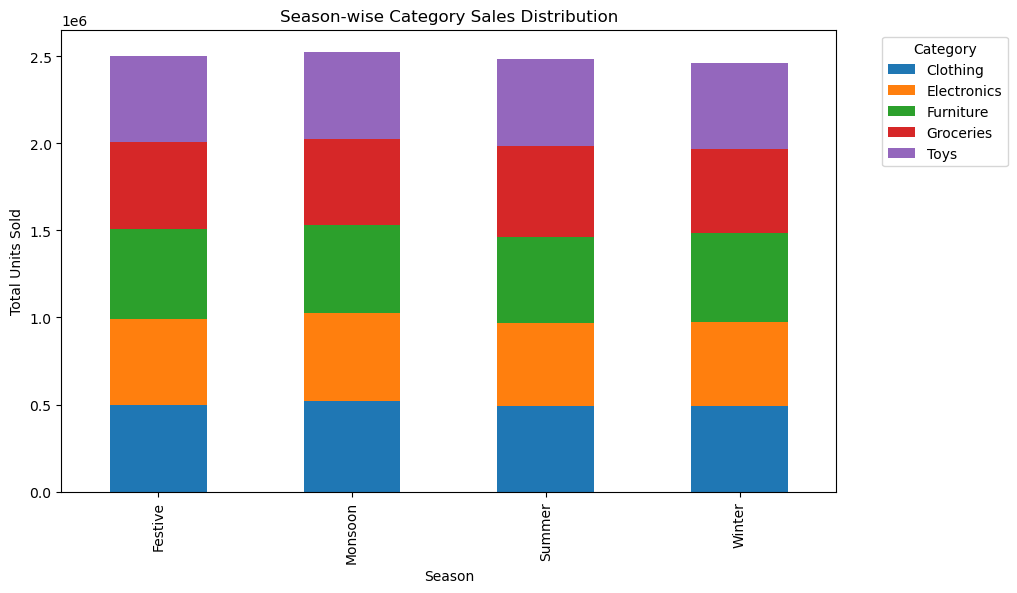

In [45]:
season_category_units = (
    df.groupby(['season', 'category'])['units_sold']
    .sum()
    .unstack()
)

season_category_units.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Season-wise Category Sales Distribution')
plt.xlabel('Season')
plt.ylabel('Total Units Sold')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1))
plt.show()
#the above bar graph shown being stacked o each other tells us about the categories wise performance during various season


In [50]:
df['performance_segment'] = np.where(
    df['inventory_turnover'] >= turnover_75,
    'Top 25% Performers',
    'Remaining 75%'
)



In [51]:
segment_comparison = (
    df.groupby('performance_segment')['revenue']
    .mean()
)


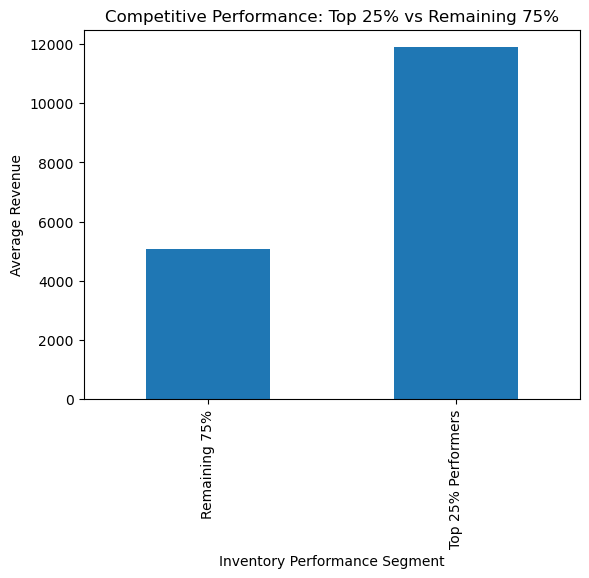

In [52]:
segment_comparison.plot(kind='bar')
plt.title('Competitive Performance: Top 25% vs Remaining 75%')
plt.xlabel('Inventory Performance Segment')
plt.ylabel('Average Revenue')
plt.show()
#the below graph shows the competetive performance between the top 25th percentile and 75th percentile of inventory
#and is devided on the basis of revenue : how much revnue they are generating

In [99]:
upper_limit = df['effective_price'].quantile(0.95)

df_filtered = df[df['effective_price'] <= upper_limit]

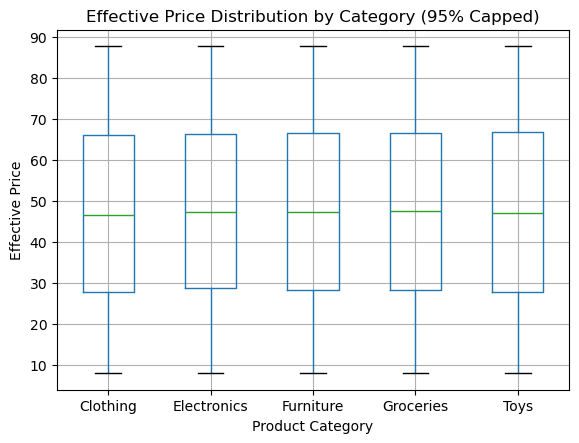

In [100]:
df_filtered.boxplot(column='effective_price', by='category')
plt.title('Effective Price Distribution by Category (95% Capped)')
plt.suptitle('')
plt.xlabel('Product Category')
plt.ylabel('Effective Price')
plt.show()


In [79]:
def walmart_login():
    while True:
        name = input("Enter Walmart Manager Name: ")
        password = input("Enter Password: ")

        if password == "walmart123":
            print(f"\nWelcome {name}! Access granted.\n")
            break
        else:
            print("\nIncorrect password. Please try again.\n")



In [80]:
def select_product_store(df):
    print("Available Categories:", df['category'].unique())
    category = input("Select Product Category: ")

    print("\nAvailable Stores:", df['store_id'].unique())
    store = input("Select Store ID: ")

    return category, store


In [81]:
def store_performance(df, category, store):
    data = df[
        (df['category'] == category) &
        (df['store_id'] == store)
    ]

    if data.empty:
        print("\nNo data found for the selected inputs.\n")
        return

    summary = (
        data.groupby('month')
        .agg(
            total_revenue=('revenue', 'sum'),
            units_sold=('units_sold', 'sum'),
            avg_inventory_turnover=('inventory_turnover', 'mean'),
            avg_forecast_error=('absolute_forecast_error', 'mean')
        )
    )

    print("\n📈 Monthly Performance Summary\n")
    print(summary)


In [82]:
def select_category_store(df):
    print("Available Categories:")
    print(df['category'].unique())

    category = input("Select Product Category: ")

    print("\nAvailable Stores:")
    print(df['store_id'].unique())

    store = input("Select Store ID: ")

    return category, store



In [87]:
def walmart_manager_login(df):
    walmart_login()               
    category, store = select_category_store(df)
    show_performance(df, category, store)



In [91]:
walmart_manager_login(df)



Enter Walmart Manager Name:  Yash Vardhan
Enter Password:  walmart123



Welcome Yash Vardhan! Access granted.

Available Categories:
['Groceries' 'Toys' 'Electronics' 'Furniture' 'Clothing']


Select Product Category:  Electronics



Available Stores:
['S001' 'S002' 'S003' 'S004' 'S005']


Select Store ID:  S003



📈 Monthly Performance Summary

       total_revenue  units_sold  avg_inventory_turnover  avg_forecast_error
month                                                                       
1       1.800830e+06       36045                0.504845            8.348594
2       1.334750e+06       27538                0.486678            7.944515
3       1.803902e+06       35505                0.504534            8.856842
4       1.493484e+06       30487                0.452802            8.855714
5       1.664397e+06       32899                0.491295            8.467490
6       1.580385e+06       34111                0.475550            8.134100
7       1.658866e+06       33207                0.510959            8.111605
8       1.565260e+06       32656                0.509855            8.232087
9       1.740482e+06       35218                0.523858            8.886962
10      1.732106e+06       34718                0.491923            7.710992
11      1.634511e+06       32816            

In [105]:
df[['price', 'discount','category', 'effective_price']].head(51)
#this column shows that more or less the net effective price of a product is majorlt below $100.

,price,discount,category,effective_price
0,33.50,20,Groceries,26.8000
1,63.01,20,Toys,50.4080
2,27.99,10,Toys,25.1910
3,32.72,10,Toys,29.4480
4,73.64,0,Electronics,73.6400
5,76.83,10,Groceries,69.1470
6,34.16,10,Furniture,30.7440
7,97.99,5,Clothing,93.0905
8,20.74,10,Electronics,18.6660
9,59.99,0,Toys,59.9900
